# Caesar Brute Force

In [6]:
import os

# Obtener el directorio actual en Jupyter Notebook
directorio_actual = os.getcwd()

# Buscar el directorio raíz "Cryptography"
while not os.path.basename(directorio_actual) == "Cryptography":
    directorio_actual = os.path.dirname(directorio_actual)  # Retroceder un nivel

# Construir la ruta del archivo cifrado
ruta_archivo = os.path.join(directorio_actual, "Cifrados", "ceasar.txt")

# Verificar si el archivo existe antes de abrirlo
if os.path.exists(ruta_archivo):
    with open(ruta_archivo, "r", encoding="utf-8") as file:
        mensaje_cifrado = file.read().strip().upper()
    print(f"Archivo cargado desde: {ruta_archivo}")
else:
    print(f"❌ Error: No se encontró el archivo en {ruta_archivo}")

Archivo cargado desde: /Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Cryptography/Cifrados/ceasar.txt


In [14]:
import string
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from collections import Counter
from colorama import init, Fore, Style
from dic import words  # Importamos el diccionario de palabras en español

# Inicializar colorama
init(autoreset=True)

# 📌 Definir el alfabeto en español con la "Ñ"
ALFABETO = "ABCDEFGHIJKLMNÑOPQRSTUVWXYZ"

# 📌 Distribución teórica de frecuencias en español
distribucion_teorica = {
    "A": 12.53, "B": 1.42, "C": 4.68, "D": 5.86, "E": 13.68, "F": 0.69, "G": 1.01, "H": 0.70,
    "I": 6.25, "J": 0.44, "K": 0.02, "L": 4.97, "M": 3.15, "N": 6.71, "Ñ": 0.31, "O": 8.68,
    "P": 2.51, "Q": 0.88, "R": 6.87, "S": 7.98, "T": 4.63, "U": 3.93, "V": 0.90, "W": 0.01,
    "X": 0.22, "Y": 0.90, "Z": 0.52
}


mensaje_cifrado.strip().upper()

'JJQAOPÑLHWXAÑEJPLZECEPWHAJYLJOPWJPAARLHQYELJHWWCEHEZWZYÑEMPLCÑWBEYWYÑEMPLWCEHEZWZMWÑWWXÑAREWÑAOQJIAYWJEOILZAZABAJOWYÑQYEWHLOXÑEJZWHWYWMWYEZWZZAILZEBEYWÑÑWMEZWIAJPAAHQOLZAWHCLÑEPILOUYHWRAOYÑEMPLCÑWBEYLOQJWWYYELJJAYAOWÑEWMWÑWWJPEYEMWÑJLOWHWOBQPQÑWOWIAJWVWOZAYEXAÑOACQÑEZWZ'

## Calcular la frencuencia observable

In [15]:
def analizar_frecuencia(texto):
    """Calcula la frecuencia de letras en el texto cifrado."""
    total = len(texto)
    frecuencia = Counter(texto.upper())

    # Filtrar solo letras del alfabeto español
    frecuencia_filtrada = {letra: (frecuencia[letra] / total) * 100 for letra in distribucion_teorica.keys() if letra in frecuencia}
    
    return frecuencia_filtrada

# 📌 Calcular la frecuencia observada
frecuencia_observada = analizar_frecuencia(mensaje_cifrado)

# 📊 Crear tabla de frecuencias
tabla_frecuencia = PrettyTable(["Letra", "Frecuencia (%)", "Teórica (%)", "Diferencia (%)"])
for letra in sorted(frecuencia_observada.keys(), key=lambda x: frecuencia_observada[x], reverse=True):
    teorica = distribucion_teorica[letra]
    observada = frecuencia_observada[letra]
    diferencia = round(abs(teorica - observada), 2)
    tabla_frecuencia.add_row([letra, round(observada, 2), teorica, diferencia])

print("📊 Comparación de Frecuencias")
print(tabla_frecuencia)

📊 Comparación de Frecuencias
+-------+----------------+-------------+----------------+
| Letra | Frecuencia (%) | Teórica (%) | Diferencia (%) |
+-------+----------------+-------------+----------------+
|   W   |     15.93      |     0.01    |     15.92      |
|   E   |     10.37      |    13.68    |      3.31      |
|   A   |      8.52      |    12.53    |      4.01      |
|   Ñ   |      7.78      |     0.31    |      7.47      |
|   Y   |      7.04      |     0.9     |      6.14      |
|   J   |      6.67      |     0.44    |      6.23      |
|   L   |      6.3       |     4.97    |      1.33      |
|   Z   |      6.3       |     0.52    |      5.78      |
|   O   |      5.93      |     8.68    |      2.75      |
|   H   |      4.44      |     0.7     |      3.74      |
|   P   |      4.44      |     2.51    |      1.93      |
|   Q   |      3.33      |     0.88    |      2.45      |
|   M   |      2.96      |     3.15    |      0.19      |
|   C   |      2.59      |     4.68    |   

In [17]:
# 📌 Crear tabla de frecuencias
tabla_frecuencia = PrettyTable(["Letra", "Frecuencia", "Probabilidad (%)"])
for letra, freq in sorted(frecuencia_observada.items(), key=lambda x: x[1], reverse=True):
    tabla_frecuencia.add_row([letra, round(freq * len(texto_cifrado) / 100), round(freq, 2)])

print("📊 Análisis de Frecuencia de Caracteres")
print(tabla_frecuencia)

📊 Análisis de Frecuencia de Caracteres
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   W   |     43     |      15.93       |
|   E   |     28     |      10.37       |
|   A   |     23     |       8.52       |
|   Ñ   |     21     |       7.78       |
|   Y   |     19     |       7.04       |
|   J   |     18     |       6.67       |
|   L   |     17     |       6.3        |
|   Z   |     17     |       6.3        |
|   O   |     16     |       5.93       |
|   H   |     12     |       4.44       |
|   P   |     12     |       4.44       |
|   Q   |     9      |       3.33       |
|   M   |     8      |       2.96       |
|   C   |     7      |       2.59       |
|   I   |     6      |       2.22       |
|   B   |     5      |       1.85       |
|   X   |     4      |       1.48       |
|   R   |     3      |       1.11       |
|   U   |     1      |       0.37       |
|   V   |     1      |       0.37    

## Distribución teórica

In [18]:
def analizar_frecuencia(texto):
    """Calcula la frecuencia de letras en el texto cifrado."""
    total = len(texto)
    frecuencia = Counter(texto.upper())

    # Filtrar solo letras del alfabeto español
    frecuencia_filtrada = {letra: (frecuencia[letra] / total) * 100 for letra in distribucion_teorica.keys() if letra in frecuencia}
    
    return frecuencia_filtrada

# 📌 Calcular la frecuencia observada
frecuencia_observada = analizar_frecuencia(mensaje_cifrado)

# 📊 Crear tabla de frecuencias
tabla_frecuencia = PrettyTable(["Letra", "Frecuencia (%)", "Teórica (%)", "Diferencia (%)"])
for letra in sorted(frecuencia_observada.keys(), key=lambda x: frecuencia_observada[x], reverse=True):
    teorica = distribucion_teorica[letra]
    observada = frecuencia_observada[letra]
    diferencia = round(abs(teorica - observada), 2)
    tabla_frecuencia.add_row([letra, round(observada, 2), teorica, diferencia])

print("📊 Comparación de Frecuencias")
print(tabla_frecuencia)

📊 Comparación de Frecuencias
+-------+----------------+-------------+----------------+
| Letra | Frecuencia (%) | Teórica (%) | Diferencia (%) |
+-------+----------------+-------------+----------------+
|   W   |     15.93      |     0.01    |     15.92      |
|   E   |     10.37      |    13.68    |      3.31      |
|   A   |      8.52      |    12.53    |      4.01      |
|   Ñ   |      7.78      |     0.31    |      7.47      |
|   Y   |      7.04      |     0.9     |      6.14      |
|   J   |      6.67      |     0.44    |      6.23      |
|   L   |      6.3       |     4.97    |      1.33      |
|   Z   |      6.3       |     0.52    |      5.78      |
|   O   |      5.93      |     8.68    |      2.75      |
|   H   |      4.44      |     0.7     |      3.74      |
|   P   |      4.44      |     2.51    |      1.93      |
|   Q   |      3.33      |     0.88    |      2.45      |
|   M   |      2.96      |     3.15    |      0.19      |
|   C   |      2.59      |     4.68    |   

## Gráficos

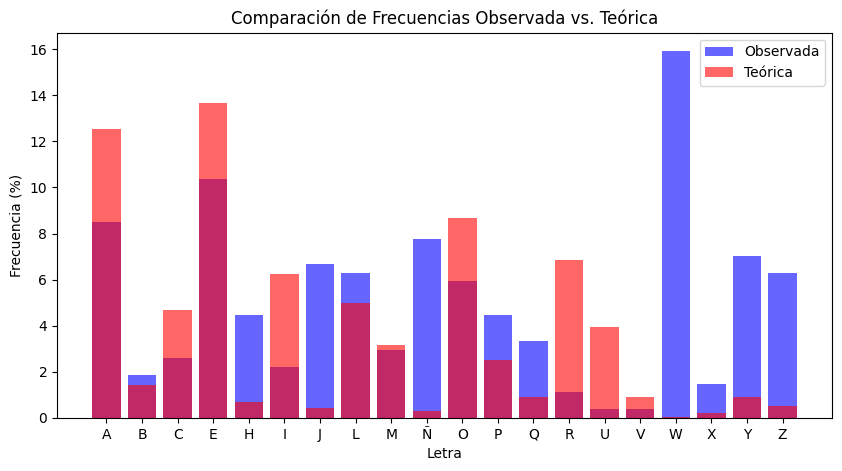

In [19]:
import matplotlib.pyplot as plt

letras = list(frecuencia_observada.keys())
observada = [frecuencia_observada[letra] for letra in letras]
teorica = [distribucion_teorica[letra] for letra in letras]

plt.figure(figsize=(10, 5))
plt.bar(letras, observada, alpha=0.6, label="Observada", color="blue")
plt.bar(letras, teorica, alpha=0.6, label="Teórica", color="red")
plt.xlabel("Letra")
plt.ylabel("Frecuencia (%)")
plt.title("Comparación de Frecuencias Observada vs. Teórica")
plt.legend()
plt.show()

In [20]:
# 📌 Determinar la clave probable con base en la diferencia mínima
letra_mas_comun = max(frecuencia_observada, key=frecuencia_observada.get)
letra_mas_comun_esperada = max(distribucion_teorica, key=distribucion_teorica.get)

# 📌 Diferencia de desplazamiento en el alfabeto
desplazamiento_estimado = (ALFABETO.index(letra_mas_comun) - ALFABETO.index(letra_mas_comun_esperada)) % len(ALFABETO)

print(f"🔑 Clave probable estimada (Cifrado César): {desplazamiento_estimado}")

🔑 Clave probable estimada (Cifrado César): 19


La W aparece muchas veces (15.93%), pero en español casi nunca se usa (0.01%). Esto nos dice que W podría ser una E o una A, que son letras muy comunes en español.

Al comparar con el español normal, parece que el mensaje fue cambiado con un desplazamiento de 19 en el Cifrado César. Eso significa que cada letra pudo haber sido movida 19 lugares en el alfabeto.

In [21]:
def descifrar_cesar(texto, shift):
    """Descifra un texto con un desplazamiento dado en el Cifrado César."""
    resultado = ""
    for char in texto:
        if char in ALFABETO:
            indice = (ALFABETO.index(char) - shift) % len(ALFABETO)
            resultado += ALFABETO[indice]
        else:
            resultado += char  # Mantener otros caracteres
    return resultado

def contar_palabras_validas(texto, diccionario):
    """Intenta encontrar palabras en el texto sin espacios comparando con un diccionario."""
    palabras_encontradas = 0
    for i in range(len(texto)):
        for j in range(i + 2, len(texto) + 1):  # Busca palabras de mínimo 2 letras
            if texto[i:j].lower() in diccionario:
                palabras_encontradas += 1
    return palabras_encontradas

def fuerza_bruta_cesar(mensaje):
    """Prueba todos los desplazamientos (0-26) y muestra resultados con colores."""
    
    mejor_shift = None
    mejor_texto = ""
    mejor_palabras = 0

    for shift in range(len(ALFABETO)):  
        texto_descifrado = descifrar_cesar(mensaje, shift)
        palabras_validas = contar_palabras_validas(texto_descifrado, words)

        # Determinar color basado en cantidad de palabras acertadas
        color = Fore.GREEN if palabras_validas > 5 else Fore.RED

        print(f"{Fore.CYAN}Probando shift: {shift}")
        print(f"{color}Palabras acertadas: {palabras_validas}")
        print(f"{color}Resultado: {texto_descifrado[:100]}...")  # Solo imprime los primeros 100 caracteres
        print(Style.RESET_ALL)

        # Guardar el mejor resultado
        if palabras_validas > mejor_palabras:
            mejor_palabras = palabras_validas
            mejor_shift = shift
            mejor_texto = texto_descifrado

    # Mostrar el mejor resultado encontrado
    if mejor_shift is not None:
        print(f"\n{Fore.YELLOW}🔹 Posible Clave: {mejor_shift}")
        print(f"{Fore.GREEN}🔓 Mensaje Descifrado: {mejor_texto}\n")

# 📌 Ejecutar la fuerza bruta
fuerza_bruta_cesar(mensaje_cifrado)

Probando shift: 0
Palabras acertadas: 33
Resultado: JJQAOPÑLHWXAÑEJPLZECEPWHAJYLJOPWJPAARLHQYELJHWWCEHEZWZYÑEMPLCÑWBEYWYÑEMPLWCEHEZWZMWÑWWXÑAREWÑAOQJIAY...

Probando shift: 1
Palabras acertadas: 30
Resultado: IIPZÑONKGVWZNDIOKYDBDOVGZIXKIÑOVIOZZQKGPXDKIGVVBDGDYVYXNDLOKBNVADXVXNDLOKVBDGDYVYLVNVVWNZQDVNZÑPIHZX...

Probando shift: 2
Palabras acertadas: 29
Resultado: HHOYNÑMJFUVYMCHÑJXCACÑUFYHWJHNÑUHÑYYPJFOWCJHFUUACFCXUXWMCKÑJAMUZCWUWMCKÑJUACFCXUXKUMUUVMYPCUMYNOHGYW...

Probando shift: 3
Palabras acertadas: 29
Resultado: GGÑXMNLIETUXLBGNIWBZBNTEXGVIGMNTGNXXOIEÑVBIGETTZBEBWTWVLBJNIZLTYBVTVLBJNITZBEBWTWJTLTTULXOBTLXMÑGFXV...

Probando shift: 4
Palabras acertadas: 47
Resultado: FFNWLMKHDSTWKAFMHVAYAMSDWFUHFLMSFMWWÑHDNUAHFDSSYADAVSVUKAIMHYKSXAUSUKAIMHSYADAVSVISKSSTKWÑASKWLNFEWU...

Probando shift: 5
Palabras acertadas: 21
Resultado: EEMVKLJGCRSVJZELGUZXZLRCVETGEKLRELVVNGCMTZGECRRXZCZURUTJZHLGXJRWZTRTJZHLGRXZCZURUHRJRRSJVNZRJVKMEDVT...

Probando shift: 6
Palabras acertadas: 24
Resultado: DDLUJK

## Referencias

https://stackoverflow.com/questions/16291818/brute-force-caeser-cipher-python
https://dev.to/cognivibes/hacking-the-caesar-cipher-3ic1
GPT